# Molecular Vibronic Spectra Experiment

This notebook uses the SDK local application APIs to load molecular parameters, derive vibronic parameters, generate samples, and compare the resulting energy distributions.

## 1. Initialize the environment

In [1]:
import numpy as np

from jiuzhang.local.applications import (
    load_formic_acid,
    sample_vibronic_spectrum,
    vibronic_energies,
    vibronic_parameters,
)

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Sarasa UI SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 2. Load formic-acid molecular data

`ground_frequencies` and `excited_frequencies` describe the two molecular states. The Duschinsky matrix describes mode mixing, and the displacement vector describes the coordinate displacement.

In [2]:
molecule = load_formic_acid()
print('Ground frequencies:', np.around(molecule.ground_frequencies[:5], 4))
print('Excited frequencies:', np.around(molecule.excited_frequencies[:5], 4))
print('Duschinsky shape:', molecule.duschinsky_matrix.shape)

Ground frequencies: [3765.2386 3088.1826 1825.1799 1416.9512 1326.4684]
Excited frequencies: [3629.9472 3064.9143 1566.4602 1399.6554 1215.3421]
Duschinsky shape: (7, 7)


## 3. Derive vibronic parameters

`temperature` specifies the initial thermal condition. The returned squeezing and displacement values form the input to the local sampling routine.

In [3]:
parameters = vibronic_parameters(molecule, temperature=0.0)
print('Squeezing parameters:', np.around(parameters.squeezing, 4))
print('Displacement vector shape:', parameters.displacement.shape)

Squeezing parameters: [ 0.0972  0.0702  0.0208 -0.0597 -0.0749 -0.112  -0.1867]
Displacement vector shape: (7,)


## 4. Generate samples with the prepared parameters

In [4]:
reference_energies = vibronic_energies(molecule)
print('First five energies:', np.around(reference_energies[:5], 4))

First five energies: [1566.4602 4699.3806 1566.4602 4699.3806 4699.3806]


## 5. Compare energy distributions

Generated samples shape: (10, 14)
Generated energies: [3132.9204    0.     1190.9077 1566.4602 3997.1444 1566.4602 2781.8023
 4631.3745    0.     3132.9204]


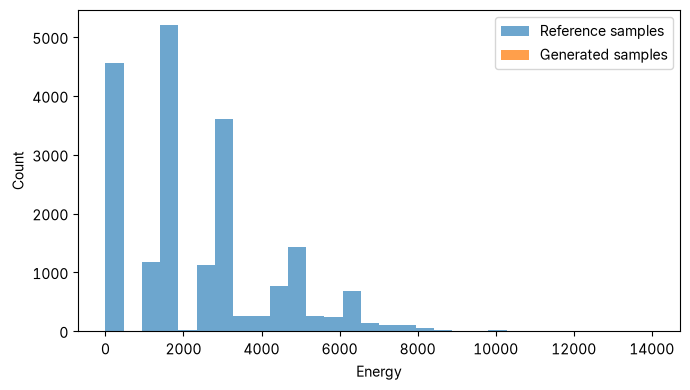

In [5]:
generated_samples = sample_vibronic_spectrum(parameters, shots=10)
generated_energies = vibronic_energies(generated_samples, molecule)

print('Generated samples shape:', generated_samples.shape)
print('Generated energies:', np.around(generated_energies, 4))

plt.figure(figsize=(7, 4))
plt.hist(reference_energies, bins=30, alpha=0.65, label='Reference samples')
plt.hist(generated_energies, bins=10, alpha=0.75, label='Generated samples')
plt.xlabel('Energy')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()